
# Блок 3. Продвинутый уровень. Занятие 15

# Финансовый анализ и прогнозирование

## Теория

Сегодня изучаем основы финансовой аналитики на реальном датасете.

Будем использовать открытый датасет фондового рынка S&P500:

https://raw.githubusercontent.com/datasets/s-and-p-500/master/data/data.csv

### Описание колонок

| Колонка | Описание |
|----------|----------|
| Date | дата торгов |
| SP500 | значение индекса S&P500 |

S&P500 — один из самых известных фондовых индексов мира.

---

## Что будем делать

- загружать финансовые данные;
- строить временные ряды;
- вычислять изменения;
- строить скользящее среднее;
- делать простой прогноз;
- анализировать тренды.

---

## Практическое применение

Похожие задачи используются:

- в банках;
- инвестиционных компаниях;
- бизнес-аналитике;
- прогнозировании продаж;
- анализе прибыли компаний.

---

## Связь с дипломом

Такие методы пригодятся:

- анализ продаж;
- анализ выручки;
- анализ клиентов;
- анализ недвижимости;
- анализ тренировок;
- анализ питания.


Сначала изучите SOLVED-ноутбук, затем выполните TODO самостоятельно.

## Ячейка 1. TODO: импорт библиотек

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime

assert pd is not None


## Ячейка 2. TODO: загрузите финансовый датасет

In [109]:
import random

file_path = r"..\..\data\diet_diary.csv"

# Загрузка с указанием кодировки (latin-1 для совместимости)
df_raw = pd.read_csv(file_path, encoding="latin-1")

unique_users = df_raw["ID"].unique()
print("Уникальных ID:", len(unique_users) )

# Выбираем первого пользователя
user_id = random.choice(unique_users)
df = df_raw[df_raw["ID"] == user_id].copy()

print("Размер загруженных данных:", df.shape)
display(df.head())
assert len(df) > 1, "Данных должно быть больше 30 дней"




Уникальных ID: 611
Размер загруженных данных: (13, 7)


,ID,date,breakfast,lunch,supper,start_weight,weight
2777,823be95a766a534757b443f4b167dd20,2018/9/4,breakfast/224282_20180904_breakfast_1536018552...,lunch/224282_20180904_lunch_1536042490.jpg|||m...,supper/224282_20180904_supper_1536062497.jpg||...,69.0,69.0
2778,823be95a766a534757b443f4b167dd20,2018/9/5,breakfast/224282_20180905_breakfast_1536104681...,lunch/224282_20180905_lunch_1536145821.jpg|||s...,supper/224282_20180905_supper_1536145912.jpg||...,69.0,68.7
2779,823be95a766a534757b443f4b167dd20,2018/9/6,breakfast/224282_20180906_breakfast_1536191631...,lunch/224282_20180906_lunch_1536219610.jpg|||o...,supper/224282_20180906_supper_1536232160.jpg|||,68.7,69.0
2780,823be95a766a534757b443f4b167dd20,2018/9/7,breakfast/224282_20180907_breakfast_1536279869...,lunch/224282_20180907_lunch_1536311781.jpg|||p...,supper/224282_20180907_supper_1536321355.jpg|||,69.0,69.0
2781,823be95a766a534757b443f4b167dd20,2018/9/8,breakfast/224282_20180908_breakfast_1536362626...,lunch/224282_20180908_lunch_1536386790.jpg|||s...,supper/224282_20180908_supper_1536411645.jpg||...,69.0,69.5


## Ячейка 3. TODO: изучите структуру данных

In [110]:
print(df.shape)
print(df.columns.tolist())

df.info()


(13, 7)
['ID', 'date', 'breakfast', 'lunch', 'supper', 'start_weight', 'weight']
<class 'pandas.DataFrame'>
RangeIndex: 13 entries, 2777 to 2789
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            13 non-null     str    
 1   date          13 non-null     str    
 2   breakfast     13 non-null     str    
 3   lunch         13 non-null     str    
 4   supper        13 non-null     str    
 5   start_weight  13 non-null     float64
 6   weight        13 non-null     float64
dtypes: float64(2), str(5)
memory usage: 860.0 bytes


## Ячейка 4. TODO: преобразуйте дату

In [111]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

print(df.dtypes)

assert str(df["date"].dtype).startswith("datetime")


ID                         str
date            datetime64[us]
breakfast                  str
lunch                      str
supper                     str
start_weight           float64
weight                 float64
dtype: object


## Ячейка 5. TODO: постройте график индекса

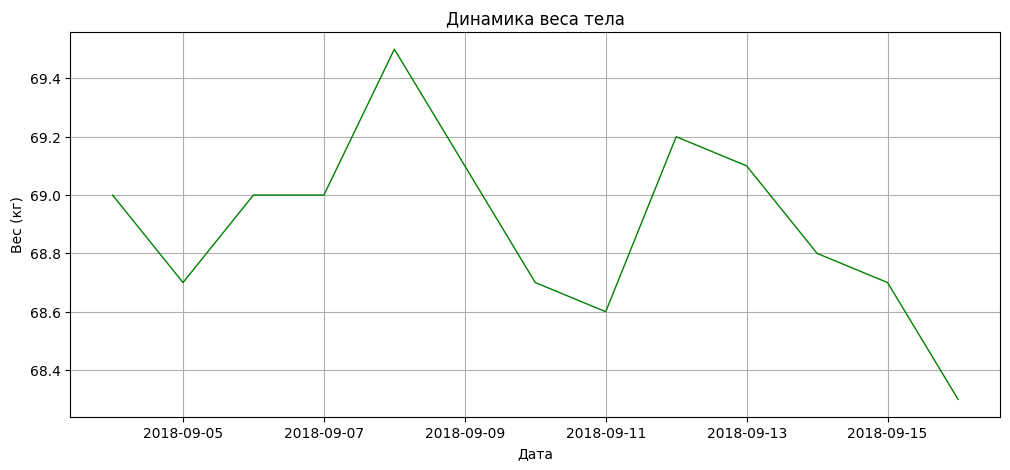

In [112]:
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["weight"], color="green", linewidth=1)
plt.title("Динамика веса тела")
plt.xlabel("Дата")
plt.ylabel("Вес (кг)")
plt.grid(True)
plt.show()


## Ячейка 6. TODO: вычислите изменения индекса

In [113]:
df["delta_weight"] = df["weight"].diff()
print("Первые строки с изменениями:")
display(df[["date", "weight", "delta_weight"]].head(10))


Первые строки с изменениями:


,date,weight,delta_weight
0,2018-09-04,69.0,NaN
1,2018-09-05,68.7,-0.3
2,2018-09-06,69.0,0.3
3,2018-09-07,69.0,0.0
4,2018-09-08,69.5,0.5
5,2018-09-09,69.1,-0.4
6,2018-09-10,68.7,-0.4
7,2018-09-11,68.6,-0.1
8,2018-09-12,69.2,0.6
9,2018-09-13,69.1,-0.1


## Ячейка 7. TODO: создайте скользящее среднее

In [114]:
n_rolling = 3
df["ma7"] = df["weight"].rolling(window=n_rolling).mean()

display(df[["ID", "weight", "ma7"]].head(40))

assert "ma7" in df.columns


,ID,weight,ma7
0,823be95a766a534757b443f4b167dd20,69.0,NaN
1,823be95a766a534757b443f4b167dd20,68.7,NaN
2,823be95a766a534757b443f4b167dd20,69.0,68.900000
3,823be95a766a534757b443f4b167dd20,69.0,68.900000
4,823be95a766a534757b443f4b167dd20,69.5,69.166667
5,823be95a766a534757b443f4b167dd20,69.1,69.200000
6,823be95a766a534757b443f4b167dd20,68.7,69.100000
7,823be95a766a534757b443f4b167dd20,68.6,68.800000
8,823be95a766a534757b443f4b167dd20,69.2,68.833333
9,823be95a766a534757b443f4b167dd20,69.1,68.966667


## Ячейка 8. TODO: постройте сравнительный график

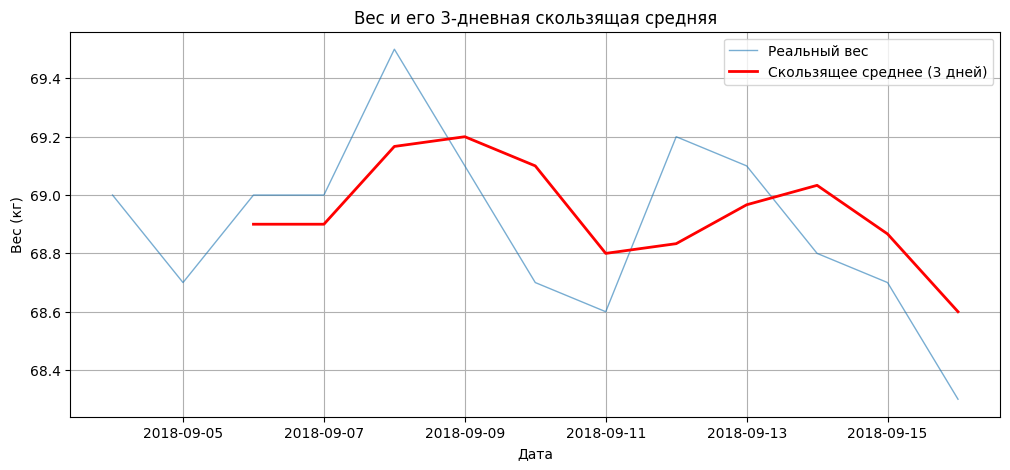

In [115]:
plt.figure(figsize=(12, 5))
plt.plot(df["date"], df["weight"], label="Реальный вес", alpha=0.6, linewidth=1)
plt.plot(
    df["date"], df["ma7"], label=f"Скользящее среднее ({n_rolling} дней)", color="red", linewidth=2
)
plt.title(f"Вес и его {n_rolling}-дневная скользящая средняя")
plt.xlabel("Дата")
plt.ylabel("Вес (кг)")
plt.legend()
plt.grid(True)
plt.show()


## Ячейка 9. TODO: сделайте простой прогноз

In [116]:
forecast = df["weight"].tail(30).mean()

print("Прогноз:", forecast)

assert forecast > 0


Прогноз: 68.89999999999999


## Ячейка 10. TODO: сформируйте отчет и assert

In [118]:
report = {
    "rows": len(df),
    "min": df["weight"].min(),
    "max": df["weight"].max(),
    "mean": df["weight"].mean(),
    "forecast": forecast,
}

for k, v in report.items():
    print(k, ":", v)

assert report["rows"] > 1


rows : 13
min : 68.3
max : 69.5
mean : 68.89999999999999
forecast : 68.89999999999999
